# **Graph Neural Networks Basics**

# What Are Tensors

Tensors are n-dimensional arrays with n > 2

In [1]:
import numpy as np
x = np.array([
    [
        [1, 2, 3],
        [5, 2, 7],
        [9, 3, 6]
    ],
    [
        [4, 1, 4],
        [6, 4, 1],
        [7, 1, 7]
    ],
    [
        [8, 7, 5],
        [5, 4, 6],
        [7, 2, 8]
    ]
])
print("X:\n", x)
print("\nDimension of X:\n", x.ndim)

X:
 [[[1 2 3]
  [5 2 7]
  [9 3 6]]

 [[4 1 4]
  [6 4 1]
  [7 1 7]]

 [[8 7 5]
  [5 4 6]
  [7 2 8]]]

Dimension of X:
 3


Installing Libraries

In [72]:
# 1st change runtime to 'GPU' or 'T4 GPU'
!python -c "import torch; print(torch.version.cuda)"

12.1


In [3]:
# To ensure compatibility with PyTorch Geometric's pre-compiled wheels for CUDA 12.x in Colab,
# it's often necessary to install a specific, known-working PyTorch version.
# We will install PyTorch 2.3.0 with CUDA 12.1 (which works with Colab's CUDA 12.8 drivers).
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

# Now, install torch-scatter and torch-sparse using the correct PyG wheel links for PyTorch 2.3.0+cu121
# Use --force-reinstall in case partial installations are present.
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.3.0+cu121.html --force-reinstall

# Finally, install torch-geometric
!pip install torch_geometric

print("\n--- Verification After Installation ---")
import torch
import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version (detected by PyTorch): {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"torch_geometric version: {torch_geometric.__version__}")

# It's often recommended to restart the runtime after significant library installations/reinstallations.
# Go to 'Runtime' -> 'Restart runtime' if you encounter further issues.

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://data.pyg.org/whl/torch-2.3.0+cu121.html
  Using cached https://data.pyg.org/whl/torch-2.3.0%2Bcu121/torch_scatter-2.1.2%2Bpt23cu121-cp312-cp312-linux_x86_64.whl (10.9 MB)
  Using cached https://data.pyg.org/whl/torch-2.3.0%2Bcu121/torch_sparse-0.6.18%2Bpt23cu121-cp312-cp312-linux_x86_64.whl (5.1 MB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached numpy-2.5.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
  Attempting uninstall: torch-scatter
    Found existing installation: torch_scatter 2.1.2+pt23cu121
    Uninstalling torch_scatter-2.1.2+pt23cu121:
      Successfully uninstalled torch_scatter-2.1.2+pt23cu121
  A


--- Verification After Installation ---


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


PyTorch version: 2.3.0+cu121
CUDA version (detected by PyTorch): 12.1
CUDA available: True
torch_geometric version: 2.8.0


# Datasets Conversion to NetworkX Graphs

In [4]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import networkx as nx

1, ENZYMES Dataset

Length of the dataset:  600
Number of classes:  6
Number of node features:  3

dataset[0]:  Data(edge_index=[2, 168], x=[37, 3], y=[1])

Type of the dataset:  <class 'torch_geometric.data.data.Data'>

Type of the converted dataset to networkx graph:  <class 'networkx.classes.digraph.DiGraph'>


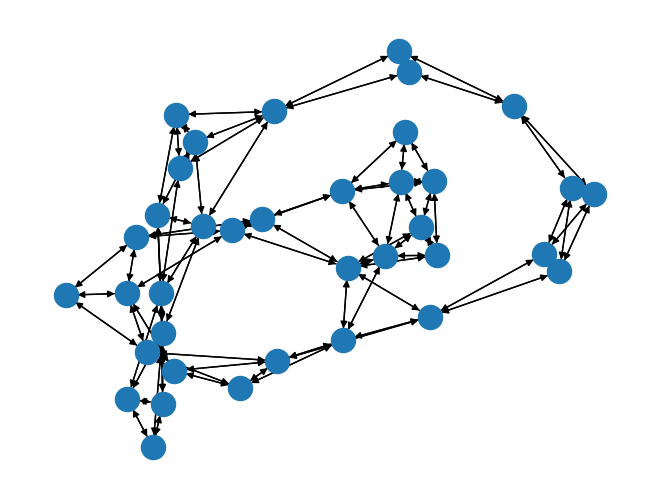

In [5]:
# Importing Dataset
from torch_geometric.datasets import TUDataset
dataset = TUDataset(root="/tmp/ENZYMES", name="ENZYMES")
print("Length of the dataset: ", len(dataset))
print("Number of classes: ", dataset.num_classes)
print("Number of node features: ", dataset.num_node_features)

data = dataset[0]
print("\ndataset[0]: ", data)
# data.edge_index: shape [2, num_edges]
# data.x: Node feature matrix with shape [num_nodes, node_features]
# data.y: Target to train against, may have arbitrary shape i.e., node-level targets of shape [num_nodes, *] or graph level targets of shape [1, *].

# Type of dataset before converting to networkx graph
print("\nType of the dataset: ", type(data))


# Converting dataset to NetworkX
networkx_graph = to_networkx(data)
print("\nType of the converted dataset to networkx graph: ", type(networkx_graph))

# Visualizing the graph
nx.draw(networkx_graph)


2, CORA Dataset

In [6]:
# Importing dataset
from torch_geometric.datasets import Planetoid
cora_dataset = Planetoid(root = "/tmp/Cora", name = "CORA")
print("Length of the cora dataset: ", len(cora_dataset))
print("Number of features: ",cora_dataset.num_features)
print("Number of classes: ", cora_dataset.num_classes)

cora_data = cora_dataset[0]
print("\ncora_dataset[0]: ", cora_data)
print("Number of nodes: ", cora_data.num_nodes)
print("Number of edges: ", cora_data.num_edges)
print("Is Directed: ", cora_data.is_directed)

print("\nShape of 0th row in features: ", cora_data.x[:0].shape)
print("Shape of 1st row in features: ", cora_data.x[:1].shape)
print("Shape of 2nd row in features: ", cora_data.x[:2].shape)

# Taking 5th row feature
cora_data_5 = cora_data.x[:5]
print("\nNumber of graphs in cora_data_5: ", len(cora_data_5))
print("Number of features in cora_data_5: ", len(cora_data_5[0]))



Length of the cora dataset:  1
Number of features:  1433
Number of classes:  7

cora_dataset[0]:  Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
Number of nodes:  2708
Number of edges:  10556
Is Directed:  <bound method BaseData.is_directed of Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])>

Shape of 0th row in features:  torch.Size([0, 1433])
Shape of 1st row in features:  torch.Size([1, 1433])
Shape of 2nd row in features:  torch.Size([2, 1433])

Number of graphs in cora_data_5:  5
Number of features in cora_data_5:  1433


Processing...
Done!


Training & Testing Information

In [7]:
# Checking training nodes
print("Number of nodes to train on: ", cora_data.train_mask.sum().item())
# Checking test nodes
print("Number of nodes to test on: ", cora_data.test_mask.sum().item())
# Checking validation nodes
print("Number of nodes to validate on: ", cora_data.val_mask.sum().item())

Number of nodes to train on:  140
Number of nodes to test on:  1000
Number of nodes to validate on:  500


Converting Cora Dataset to NetworkX Graph

Type of the cora dataset:  <class 'torch_geometric.data.data.Data'>

Type of the cora dataset:  <class 'networkx.classes.digraph.DiGraph'>


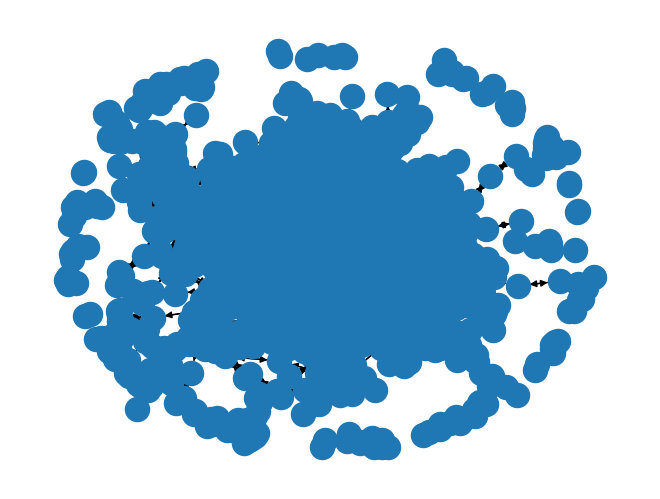

In [8]:
# Type of cora dataset before converting to networkx graph
print("Type of the cora dataset: ", type(cora_data))

# Converting
networkx_graph_cora = to_networkx(cora_data)
print("\nType of the cora dataset: ", type(networkx_graph_cora))

nx.draw(networkx_graph_cora)

In [9]:
type(cora_data_5)

torch.Tensor

Saving the graph

In [10]:
# In '.gexf' format
nx.write_gexf(networkx_graph_cora, "cora_graph.gexf")
# OR in '.graphml' format
nx.write_graphml(networkx_graph_cora, "cora_graph.graphml")

# Cora Dataset From NetworkX

Download Cora.tgz file from the link below,

(https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz)


In [11]:
# Unzipping
!tar -xvf /content/cora.tgz

cora/
cora/README
cora/cora.cites
cora/cora.content


In [12]:
import os
import networkx as pd
import pandas as pd
data_dir = os.path.expanduser("/content/cora")

In [13]:
edgelist = pd.read_csv(os.path.join(data_dir, "cora.cites"), sep="\t", header=None, names=["target", "source"])
edgelist["label"] = "cites"

In [14]:
edgelist.sample(frac=1).head() # 'sample(frac=1)' means to shuffle the dataset 100% and pick random values from it.

,target,source,label
6,35,1109199,cites
3595,73162,653441,cites
1298,6214,1115886,cites
2697,30895,1154251,cites
3018,39130,39131,cites


In [15]:
# Converting pandas dataframe to networkx format
Gnx = nx.from_pandas_edgelist(edgelist, edge_attr="label")
nx.set_node_attributes(Gnx, "paper", "label")

In [24]:
Gnx

In [16]:
print(nx.is_weighted(Gnx))
print(nx.is_directed(Gnx))
print(Gnx.order())
print(Gnx.number_of_edges())
print(Gnx.number_of_nodes())
print(Gnx.edges)
print(Gnx.nodes)

False
False
2708
5278
2708
[(1033, 35), (1033, 1034), (1033, 1107062), (1033, 41714), (1033, 45605), (35, 103482), (35, 103515), (35, 1050679), (35, 1103960), (35, 1103985), (35, 1109199), (35, 1112911), (35, 1113438), (35, 1113831), (35, 1114331), (35, 1117476), (35, 1119505), (35, 1119708), (35, 1120431), (35, 1123756), (35, 1125386), (35, 1127430), (35, 1127913), (35, 1128204), (35, 1128227), (35, 1128314), (35, 1128453), (35, 1128945), (35, 1128959), (35, 1128985), (35, 1129018), (35, 1129027), (35, 1129573), (35, 1129683), (35, 1129778), (35, 1130847), (35, 1130856), (35, 1131116), (35, 1131360), (35, 1131557), (35, 1131752), (35, 1133196), (35, 1133338), (35, 1136814), (35, 1137466), (35, 1152421), (35, 1152508), (35, 1153065), (35, 1153280), (35, 1153577), (35, 1153853), (35, 1153943), (35, 1154176), (35, 1154459), (35, 116552), (35, 12576), (35, 128540), (35, 132806), (35, 135130), (35, 141342), (35, 141347), (35, 148170), (35, 15670), (35, 1688), (35, 175291), (35, 178727), (3

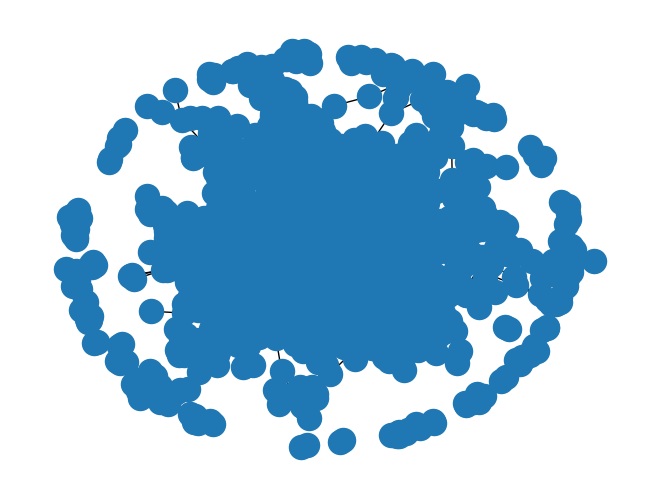

In [25]:
nx.draw(Gnx)

In [18]:
Gnx.nodes[47682]

{'label': 'paper'}

In [19]:
feature_names = ["w_{}".format(ii) for ii in range(1433)]
column_names = feature_names + ["subject"]
node_data = pd.read_csv(os.path.join(data_dir, "cora.content"), sep="\t", header=None, names=column_names)

In [20]:
node_data

,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7,w_8,w_9,...,w_1424,w_1425,w_1426,w_1427,w_1428,w_1429,w_1430,w_1431,w_1432,subject
31336,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1061127,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
1106406,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
13195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
37879,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128975,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
1128977,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
1128978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
117328,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Case_Based


In [22]:
set(node_data["subject"])

{'Case_Based',
 'Genetic_Algorithms',
 'Neural_Networks',
 'Probabilistic_Methods',
 'Reinforcement_Learning',
 'Rule_Learning',
 'Theory'}

In [23]:
node_data

,w_0,w_1,w_2,w_3,w_4,w_5,w_6,w_7,w_8,w_9,...,w_1424,w_1425,w_1426,w_1427,w_1428,w_1429,w_1430,w_1431,w_1432,subject
31336,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,Neural_Networks
1061127,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,Rule_Learning
1106406,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
13195,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Reinforcement_Learning
37879,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Probabilistic_Methods
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128975,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
1128977,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
1128978,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Genetic_Algorithms
117328,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Case_Based


In [27]:
# Adjacency matrix
A = nx.adjacency_matrix(Gnx)
A.todense()

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 1],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 0, 0]], shape=(2708, 2708))

# Example - 1

Creating Data

In [40]:
from torch_geometric.data import Data
# Number of edges
edge_index = torch.tensor([[0, 1, 1, 2],
                           [1, 0, 2, 3]], dtype=torch.long) # 1st row 'source nodes', 2nd row 'target nodes'
# Feature matrix
x = torch.tensor([[-1], [0], [1]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index)

In [50]:
print("Edge index dimensions: ", edge_index.ndim)
print("X dimensions: ", x.ndim)

Edge index dimensions:  2
X dimensions:  2


In [41]:
print("Data: ", data, "\n")
print("Edge Index:\n", edge_index, "\n")
print("Features X:\n", x)

Data:  Data(x=[3, 1], edge_index=[2, 4]) 

Edge Index:
 tensor([[0, 1, 1, 2],
        [1, 0, 2, 3]]) 

Features X:
 tensor([[-1.],
        [ 0.],
        [ 1.]])


Converting Data to NetworkX Graph

In [42]:
from torch_geometric.utils import to_networkx
G = to_networkx(data)
print("Type of G: ", type(G))

Type of G:  <class 'networkx.classes.digraph.DiGraph'>


Drawing The Graph

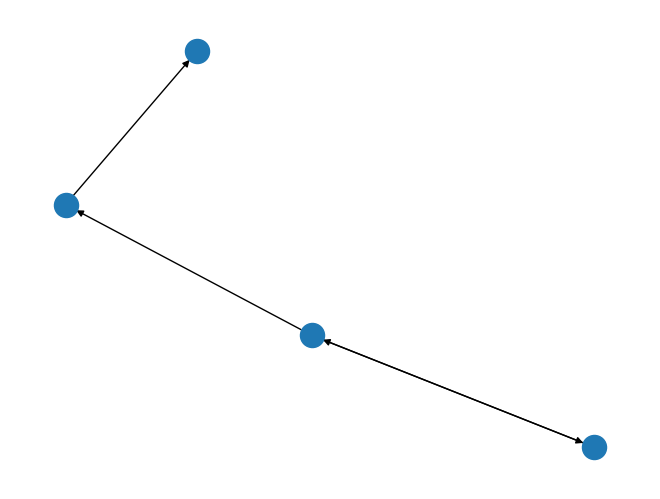

In [43]:
import networkx as nx
nx.draw(G)

In [51]:
data.keys()

['x', 'edge_index']

In [45]:
for key, item in data:
  print(f"{key} found in data")

x found in data
edge_index found in data


In [46]:
"edge_attr" in data

False

In [48]:
print("Number of nodes: ", data.num_nodes)
print("Number of edges: ", data.num_edges)
print("Number of node features: ", data.num_node_features)
print("Isolated nodes: ", data.has_isolated_nodes())
print("Self looping: ", data.has_self_loops())
print("Is directed: ", data.is_directed())

Number of nodes:  3
Number of edges:  4
Number of node features:  1
Isolated nodes:  False
Self looping:  False
Is directed:  True


In [49]:
x.ndim

2

Example - 2

# Creating the data

In [59]:
edge_index = torch.tensor([[1, 2, 3, 4],
                           [2, 3, 4, 5]], dtype=torch.long)
x = torch.tensor([[[1], [2], [3]],[[3], [5], [2]]], dtype=torch.float)

data = Data(x=x, edge_index=edge_index)
print(data)

Data(x=[2, 3, 1], edge_index=[2, 4])


In [54]:
print("Edge index dimensions: ", edge_index.ndim)
print("X dimensions: ", x.ndim)

Edge index dimensions:  2
X dimensions:  3


In [53]:
data.keys()

['x', 'edge_index']

Converting Data to Networkx Graph

In [57]:
G = to_networkx(data)
print("Type of G: ", type(G))

Type of G:  <class 'networkx.classes.digraph.DiGraph'>


Drawing The Graph

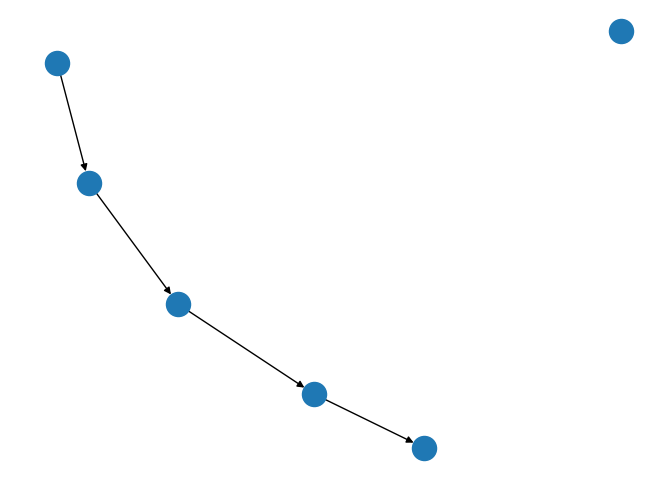

In [58]:
nx.draw(G)

Some Information About The Graph

In [66]:
print("Number of nodes: ", data.num_nodes)
print("Number of edges: ", data.num_edges)
print("Is directed: ", data.is_directed())
print("Is the graph weighted: ", nx.is_weighted(G))

Number of nodes:  2
Number of edges:  4
Is directed:  True
Is the graph weighted:  False


Saving The Graph

In [67]:
nx.write_graphml(G, "example-2.graphml")

Generating The Graph In XML Format

In [70]:
for line in nx.generate_graphml(G):
  print(line) # The node node 0 i.e., 'id = 0' gets adds up  by the functon its not in the graph also it isnot connected to any other node

<graphml xmlns="http://graphml.graphdrawing.org/xmlns" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://graphml.graphdrawing.org/xmlns http://graphml.graphdrawing.org/xmlns/1.0/graphml.xsd">
  <graph edgedefault="directed">
    <node id="0" />
    <node id="1" />
    <node id="2" />
    <node id="3" />
    <node id="4" />
    <node id="5" />
    <edge source="1" target="2" />
    <edge source="2" target="3" />
    <edge source="3" target="4" />
    <edge source="4" target="5" />
  </graph>
</graphml>


Opening The Graph In XML Format

In [71]:
!cat "/content/example-2.graphml"

<?xml version='1.0' encoding='utf-8'?>
<graphml xmlns="http://graphml.graphdrawing.org/xmlns" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation="http://graphml.graphdrawing.org/xmlns http://graphml.graphdrawing.org/xmlns/1.0/graphml.xsd"><graph edgedefault="directed"><node id="0"/>
<node id="1"/>
<node id="2"/>
<node id="3"/>
<node id="4"/>
<node id="5"/>
<edge source="1" target="2"/>
<edge source="2" target="3"/>
<edge source="3" target="4"/>
<edge source="4" target="5"/>
</graph></graphml>